#### Get dataset from Kaggle

In [1]:
# uncomment to download
!curl -L -o e-commerce-fraud-detection-dataset.zip https://www.kaggle.com/api/v1/datasets/download/umuttuygurr/e-commerce-fraud-detection-dataset
!unzip e-commerce-fraud-detection-dataset.zip -d data
!rm e-commerce-fraud-detection-dataset.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 6102k  100 6102k    0     0  4961k      0  0:00:01  0:00:01 --:--:-- 15.3M
Archive:  e-commerce-fraud-detection-dataset.zip
  inflating: data/transactions.csv   


#### Helper functions

In [24]:
def load_csv_data(csv_data_file, verbose=True):
    df = pd.read_csv(csv_data_file,
                     low_memory=False
    )
    if verbose:
        print(f"\nDataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
        print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    return df

def plot_target_distribution(df, target_col):
    # Visualize target variable distribution
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    
    # Count plot
    df[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
    axes[0].set_title(f'Target Variable ({target_col}) Distribution', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Count')
    axes[0].set_xticklabels(['Regular (0)', 'Fraud (1)'], rotation=0)
    
    # Percentage plot
    df[target_col].value_counts(normalize=True).plot(kind='bar', ax=axes[1], color=['skyblue', 'salmon'])
    axes[1].set_title(f'Target Variable ({target_col}) Distribution in %', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Percentage')
    axes[1].set_xticklabels(['Regular (0)', 'Fraud (1)'], rotation=0)
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    
    plt.tight_layout()
    plt.show()

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df = load_csv_data('data/transactions.csv')


Dataset Shape: 299695 rows, 17 columns
Memory Usage: 107.29 MB


In [8]:
df.T

,0,1,2,3,4,5,6,7,8,9,...,299685,299686,299687,299688,299689,299690,299691,299692,299693,299694
transaction_id,1,2,3,4,5,6,7,8,9,10,...,299686,299687,299688,299689,299690,299691,299692,299693,299694,299695
user_id,1,1,1,1,1,1,1,1,1,1,...,6000,6000,6000,6000,6000,6000,6000,6000,6000,6000
account_age_days,141,141,141,141,141,141,141,141,141,141,...,996,996,996,996,996,996,996,996,996,996
total_transactions_user,47,47,47,47,47,47,47,47,47,47,...,45,45,45,45,45,45,45,45,45,45
avg_amount_user,147.93,147.93,147.93,147.93,147.93,147.93,147.93,147.93,147.93,147.93,...,27.93,27.93,27.93,27.93,27.93,27.93,27.93,27.93,27.93,27.93
amount,84.75,107.9,92.36,112.47,132.91,224.82,125.98,66.95,261.58,97.34,...,14.77,22.82,33.97,22.42,100.16,34.07,68.56,25.02,23.92,26.07
country,FR,FR,FR,FR,FR,FR,FR,FR,FR,FR,...,ES,ES,ES,ES,ES,ES,ES,ES,ES,ES
bin_country,FR,FR,FR,FR,US,FR,FR,RO,FR,FR,...,ES,ES,ES,ES,ES,ES,ES,ES,ES,ES
channel,web,web,app,web,web,web,app,web,app,web,...,web,web,app,web,app,web,app,app,web,web
merchant_category,travel,travel,travel,fashion,electronics,travel,electronics,travel,grocery,electronics,...,gaming,fashion,electronics,electronics,travel,grocery,travel,fashion,gaming,gaming


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299695 entries, 0 to 299694
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           299695 non-null  int64  
 1   user_id                  299695 non-null  int64  
 2   account_age_days         299695 non-null  int64  
 3   total_transactions_user  299695 non-null  int64  
 4   avg_amount_user          299695 non-null  float64
 5   amount                   299695 non-null  float64
 6   country                  299695 non-null  object 
 7   bin_country              299695 non-null  object 
 8   channel                  299695 non-null  object 
 9   merchant_category        299695 non-null  object 
 10  promo_used               299695 non-null  int64  
 11  avs_match                299695 non-null  int64  
 12  cvv_result               299695 non-null  int64  
 13  three_ds_flag            299695 non-null  int64  
 14  tran

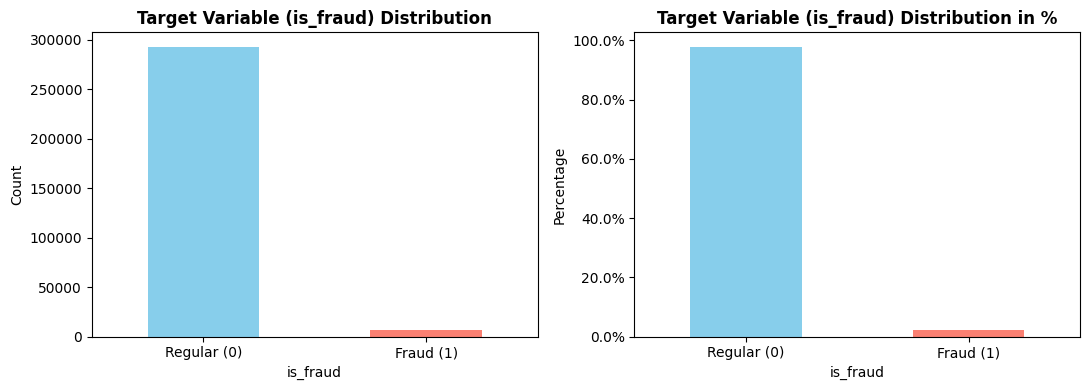

In [25]:
plot_target_distribution(df, 'is_fraud')

In [11]:
df[df.is_fraud==1].groupby('user_id').count()

,transaction_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,transaction_time,shipping_distance_km,is_fraud
user_id,,,,,,,,,,,,,,,,
3,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
10,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
13,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
22,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
25,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5984,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
5990,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
5995,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
